In [1]:
import os
os.chdir("..")

In [2]:
from src.boosted_tree import BoostedTreeClassifier
from src.features import FEATURE_SETS
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

feature_set = "all_diffs.csv"
FEATURE_COLS = FEATURE_SETS[feature_set]
df = pd.read_csv(f"data/cleaned/{feature_set}")

train_df = df[df["tourney_date"] < 20220101]
test_df  = df[df["tourney_date"] >= 20220101]

X_train = train_df[FEATURE_COLS].to_numpy().astype(float)
Y_train = train_df["p1_won"].to_numpy().astype(float)
X_val   = test_df[FEATURE_COLS].to_numpy().astype(float)
Y_val   = test_df["p1_won"].to_numpy().astype(float).reshape(-1, 1)

print("Features and labels built.")

Features and labels built.


In [3]:
boost = BoostedTreeClassifier(
    num_trees=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=99
)
print("about to fit the model!")
boost.fit(X_train, Y_train)

about to fit the model!
  fitting tree 1/100...
  fitting tree 2/100...
  fitting tree 3/100...
  fitting tree 4/100...
  fitting tree 5/100...
  fitting tree 6/100...
  fitting tree 7/100...
  fitting tree 8/100...
  fitting tree 9/100...
  fitting tree 10/100...
  fitting tree 11/100...
  fitting tree 12/100...
  fitting tree 13/100...
  fitting tree 14/100...
  fitting tree 15/100...
  fitting tree 16/100...
  fitting tree 17/100...
  fitting tree 18/100...
  fitting tree 19/100...
  fitting tree 20/100...
  fitting tree 21/100...
  fitting tree 22/100...
  fitting tree 23/100...
  fitting tree 24/100...
  fitting tree 25/100...
  fitting tree 26/100...
  fitting tree 27/100...
  fitting tree 28/100...
  fitting tree 29/100...
  fitting tree 30/100...
  fitting tree 31/100...
  fitting tree 32/100...
  fitting tree 33/100...
  fitting tree 34/100...
  fitting tree 35/100...
  fitting tree 36/100...
  fitting tree 37/100...
  fitting tree 38/100...
  fitting tree 39/100...
  fitting 

In [4]:
Y_pred, Y_confidence, tree_preds = boost.predict(X_val)
accuracy = 0

for i in range(Y_pred.shape[0]):
    if Y_pred[i] == Y_val[i]:
        accuracy += 1

accuracy = accuracy / len(Y_pred)
print("Min confidence:", Y_confidence.min())
print("Max confidence:", Y_confidence.max())
print("Mean confidence:", Y_confidence.mean())
print(accuracy)

Min confidence: 0.0
Max confidence: 0.5676374563961193
Mean confidence: 0.23643208201379717
0.6162820845216489


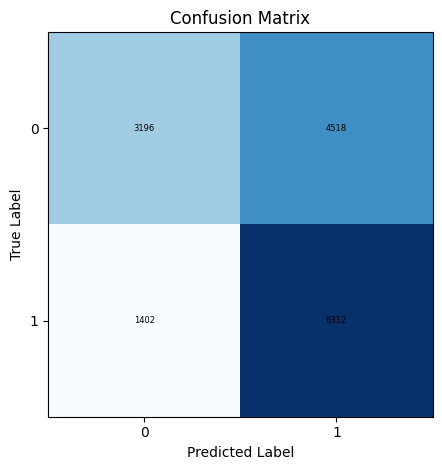

In [5]:
conf_mat = np.zeros((2, 2), dtype=int)
for true, pred in zip(Y_val.flatten(), Y_pred.flatten()):
    conf_mat[int(true), int(pred)] += 1

fig, ax = plt.subplots()
im = ax.imshow(conf_mat, cmap="Blues", origin="upper")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["0", "1"])
ax.set_yticklabels(["0", "1"])
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

for i in range(conf_mat.shape[0]):
    for j in range(conf_mat.shape[1]):
        ax.text(j, i, conf_mat[i, j].item(), ha="center", va="center", color="black", size=6)

ax.set_title("Confusion Matrix")
ax.grid(False)
plt.tight_layout()
plt.show()


In [6]:
boost.getConfidences(tree_preds)



Trees: 0, Avg confidence: 0.0000
Trees: 10, Avg confidence: 0.1610
Trees: 20, Avg confidence: 0.1942
Trees: 30, Avg confidence: 0.2108
Trees: 40, Avg confidence: 0.2137
Trees: 50, Avg confidence: 0.2137
Trees: 60, Avg confidence: 0.2140
Trees: 70, Avg confidence: 0.2136
Trees: 80, Avg confidence: 0.2142
Trees: 90, Avg confidence: 0.2139
Trees: 100, Avg confidence: 0.2156


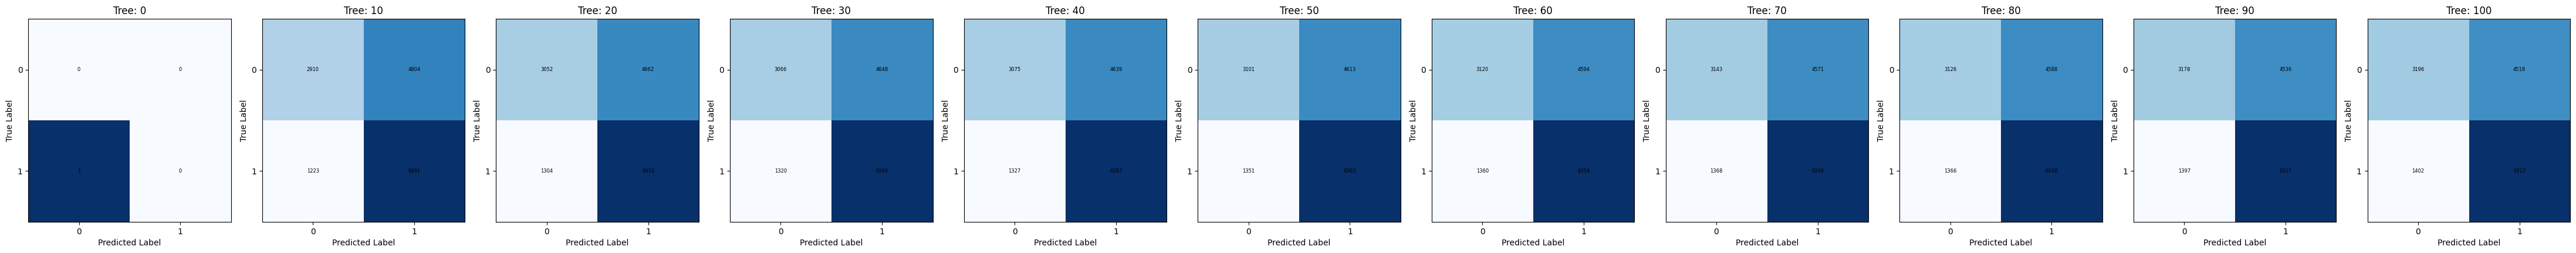

In [7]:
steps = list(range(0, len(tree_preds) + 1, 10))
fig, axes = plt.subplots(1, len(steps), figsize=(4 * len(steps), 4))

for ax, n in zip(axes, steps):
    cumulative = sum(tree_preds[:n])
    probs_n = 1 / (1 + np.exp(-cumulative))
    Y_pred_n = (probs_n > 0.5).astype(int)

    conf_mat = np.zeros((2, 2), dtype=int)
    for true, pred in zip(Y_val.flatten(), Y_pred_n.flatten()):
        conf_mat[int(true), int(pred)] += 1

    im = ax.imshow(conf_mat, cmap="Blues", origin="upper")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["0", "1"])
    ax.set_yticklabels(["0", "1"])
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

    for i in range(conf_mat.shape[0]):
        for j in range(conf_mat.shape[1]):
            ax.text(j, i, conf_mat[i, j].item(), ha="center", va="center", color="black", size=6)

    ax.set_title(f"Tree: {n}")
    ax.grid(False)

plt.tight_layout()
plt.show()